In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum11/"

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import folium

In [59]:
import pandas as pd

df = pd.read_csv(path + "data/data_gempa_sumatera.csv")

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-02T13:16:24.003Z,0.3448,98.6636,47.942,5.1,mb,155.0,41.0,2.347,0.58,...,2025-12-03T17:33:26.040Z,"99 km ESE of Teluk Dalam, Indonesia",earthquake,7.60,5.046,0.050,131.0,reviewed,us,us
1,2025-11-27T05:32:44.973Z,1.1988,96.8545,19.149,4.8,mb,41.0,189.0,2.546,0.56,...,2025-11-27T06:06:49.040Z,"85 km W of Gunungsitoli, Indonesia",earthquake,5.08,6.256,0.093,36.0,reviewed,us,us
2,2025-11-27T04:56:26.540Z,2.6921,96.0266,25.388,6.6,mww,42.0,81.0,2.894,1.18,...,2025-11-28T05:17:05.261Z,"45 km WNW of Sinabang, Indonesia",earthquake,9.36,5.993,0.062,25.0,reviewed,us,us
3,2025-11-26T19:54:23.495Z,0.7250,96.7871,10.000,5.0,mb,81.0,90.0,2.895,1.01,...,2025-11-26T20:41:43.040Z,"111 km SW of Gunungsitoli, Indonesia",earthquake,8.72,1.666,0.068,68.0,reviewed,us,us
4,2025-11-26T05:28:38.547Z,2.4703,98.9235,156.190,4.9,mb,39.0,142.0,0.222,1.05,...,2025-11-26T05:43:04.040Z,"21 km SSE of Tomok Bolon, Indonesia",earthquake,10.84,5.018,0.106,28.0,reviewed,us,us


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             12763 non-null  object 
 1   latitude         12763 non-null  float64
 2   longitude        12763 non-null  float64
 3   depth            12763 non-null  float64
 4   mag              12763 non-null  float64
 5   magType          12763 non-null  object 
 6   nst              9854 non-null   float64
 7   gap              12258 non-null  float64
 8   dmin             3898 non-null   float64
 9   rms              12762 non-null  float64
 10  net              12763 non-null  object 
 11  id               12763 non-null  object 
 12  updated          12763 non-null  object 
 13  place            12763 non-null  object 
 14  type             12763 non-null  object 
 15  horizontalError  3489 non-null   float64
 16  depthError       5995 non-null   float64
 17  magError    

In [41]:

features = df[['latitude', 'longitude']].copy()

# 3. Konversi Koordinat ke Radian untuk Haversine
# DBSCAN dengan metric='haversine' memerlukan input dalam radian
X = np.radians(features)

print(f"Data berhasil dimuat. Jumlah titik: {len(X)}")

Data berhasil dimuat. Jumlah titik: 12763


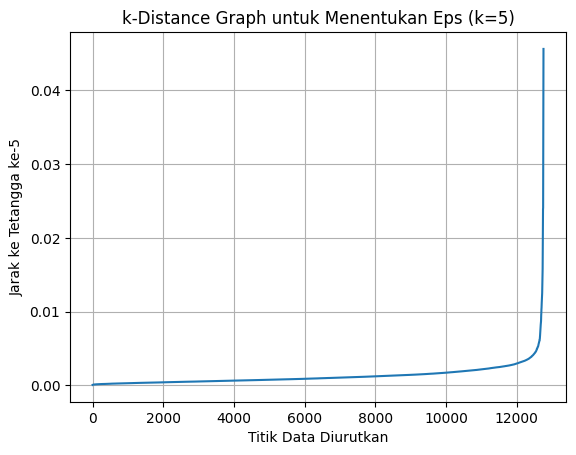


Analisis Eps: Lihat pada grafik, titik 'siku' (elbow) adalah nilai Eps yang optimal.


In [42]:
# Tentukan Min_samples
min_samples = 5
k = min_samples

# Hitung jarak ke k-tetangga terdekat (k=min_samples)
# Menggunakan metrik 'haversine' pada data dalam radian
neigh = NearestNeighbors(n_neighbors=k, metric='haversine')
neigh.fit(X)

# Dists akan berisi jarak, Inds berisi indeks tetangga
dists, ind = neigh.kneighbors(X)

# Ambil jarak ke tetangga ke-(k-1), karena indeks dimulai dari 0
# Ini adalah jarak ke tetangga ke-5 jika k=5
k_distance = dists[:, k-1]

# Urutkan jarak-jarak tersebut
k_distance = np.sort(k_distance, axis=0)

# Visualisasi k-distance graph plt.figure(figsize=(10, 6))
plt.plot(k_distance)
plt.xlabel('Titik Data Diurutkan')
plt.ylabel(f'Jarak ke Tetangga ke-{k}')
plt.title(f'k-Distance Graph untuk Menentukan Eps (k={k})')
plt.grid(True)
plt.show()

print("\nAnalisis Eps: Lihat pada grafik, titik 'siku' (elbow) adalah nilai Eps yang optimal.")
# Contoh: Jika siku di nilai 0.05, maka Eps_radian = 0.05
# Jika Anda ingin mengkonversi ke KM: Eps_km = Eps_radian * 6371 (Radius Bumi)

In [54]:
# Ganti nilai ini dengan hasil penentuan dari grafik Anda
eps_value_radian = 0.01  # Contoh nilai Eps dalam radian
min_samples_value = 100    # Min_samples yang telah ditentukan

# 1. Terapkan DBSCAN
db = DBSCAN(
    eps=eps_value_radian,
    min_samples=min_samples_value,
    metric='haversine' # Penting: Gunakan Haversine untuk data GPS
).fit(X)

labels = db.labels_

# 2. Tambahkan Label Klaster ke DataFrame asli
features['cluster'] = labels

# Hitung jumlah klaster (tanpa noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("\n=== Hasil Implementasi DBSCAN ===")
print(f"Parameter: Eps = {eps_value_radian:.4f} radian, Min_samples = {min_samples_value}")
print(f"Jumlah Klaster Ditemukan: {n_clusters}")
print(f"Jumlah Titik Noise (-1): {n_noise}")


=== Hasil Implementasi DBSCAN ===
Parameter: Eps = 0.0100 radian, Min_samples = 100
Jumlah Klaster Ditemukan: 2
Jumlah Titik Noise (-1): 500


In [55]:
print("\n=== Analisis Persebaran Klaster ===")

# Klasterisasi berdasarkan label
cluster_counts = features['cluster'].value_counts()
print("Jumlah Titik di Setiap Klaster:")
print(cluster_counts.sort_index())

# Analisis Rata-Rata Lokasi Klaster
print("\nKoordinat Rata-Rata (Pusat) Setiap Klaster:")
cluster_means = features.groupby('cluster').agg(
    lat_mean=('latitude', 'mean'),
    lon_mean=('longitude', 'mean')
)
print(cluster_means[cluster_means.index != -1])

# Analisis Noise
noise_percentage = (n_noise / len(features)) * 100
print(f"\nPersentase Noise: {noise_percentage:.2f}%")
print("Titik Noise (-1) menunjukkan gempa yang terjadi di lokasi yang 'terisolasi' dan tidak memiliki kepadatan tinggi dalam radius Eps.")

# Analisis Kepadatan
print("\nKesimpulan Analisis Densitas:")
print("Klaster dengan jumlah titik terbesar menunjukkan area-area di Sumatera yang memiliki konsentrasi aktivitas gempa tertinggi (densitas tinggi).")
print("Lokasi rata-rata klaster menunjukkan pusat-pusat kepadatan seismik.")


=== Analisis Persebaran Klaster ===
Jumlah Titik di Setiap Klaster:
cluster
-1      500
 0    12077
 1      186
Name: count, dtype: int64

Koordinat Rata-Rata (Pusat) Setiap Klaster:
         lat_mean   lon_mean
cluster                     
0        0.110332  98.305402
1        1.016819  92.095385

Persentase Noise: 3.92%
Titik Noise (-1) menunjukkan gempa yang terjadi di lokasi yang 'terisolasi' dan tidak memiliki kepadatan tinggi dalam radius Eps.

Kesimpulan Analisis Densitas:
Klaster dengan jumlah titik terbesar menunjukkan area-area di Sumatera yang memiliki konsentrasi aktivitas gempa tertinggi (densitas tinggi).
Lokasi rata-rata klaster menunjukkan pusat-pusat kepadatan seismik.


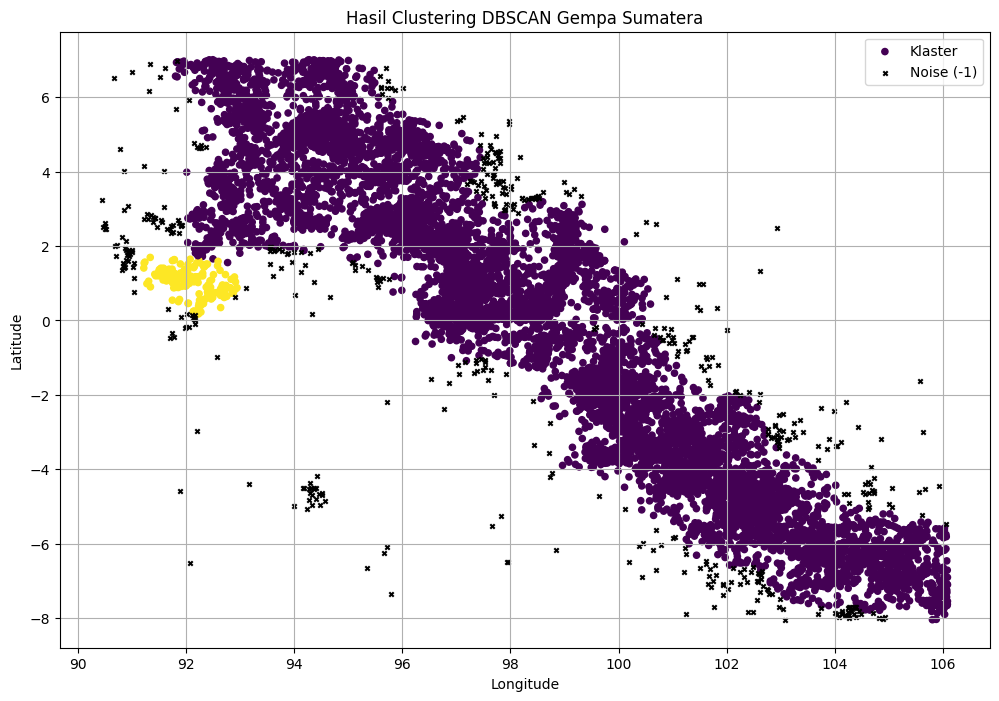

In [56]:
# Visualisasi Scatter Plot
plt.figure(figsize=(12, 8))
# Memisahkan data noise dan cluster
clustered = features[features['cluster'] != -1]
noise = features[features['cluster'] == -1]

# Plot Klaster
plt.scatter(clustered['longitude'], clustered['latitude'],
            c=clustered['cluster'], cmap='viridis', marker='o', s=20, label='Klaster')
# Plot Noise
plt.scatter(noise['longitude'], noise['latitude'],
            c='black', marker='x', s=10, label='Noise (-1)')

plt.title('Hasil Clustering DBSCAN Gempa Sumatera')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
# Tentukan pusat peta (rata-rata koordinat gempa Sumatera)
avg_lat = features['latitude'].mean()
avg_lon = features['longitude'].mean()

# Buat peta Folium
m = folium.Map(location=[avg_lat, avg_lon], zoom_start=5)

# Tentukan skema warna
unique_labels = features['cluster'].unique()
# Menghapus -1 dari daftar label unik untuk penetapan warna
cluster_labels = unique_labels[unique_labels != -1]

# Tentukan warna untuk setiap klaster (maks 10 warna, ulangi jika lebih)
colors = plt.cm.get_cmap('Spectral', len(cluster_labels))

# Iterasi dan plot setiap titik
for index, row in features.iterrows():
    lat = row['latitude']
    lon = row['longitude']
    label = row['cluster']

    if label == -1:
        # Noise: beri warna hitam
        color = 'black'
        fill_color = 'black'
        radius = 1.5
    else:
        # Klaster: beri warna dari skema warna
        color_idx = np.where(cluster_labels == label)[0][0] % colors.N
        color = colors(color_idx)[:3] # Ambil RGB
        color_hex = f'#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}'
        fill_color = color_hex
        radius = 3

    # Tambahkan marker ke peta
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color_hex if label != -1 else color,
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.6,
        tooltip=f"Klaster: {label}"
    ).add_to(m)

print("\nVisualisasi Peta GPS ")
m

Output hidden; open in https://colab.research.google.com to view.